Device  : cuda
PyTorch : 2.6.0+cu124
Data shape       : (109819, 28)
Adjacency shape  : (8, 8, 7)
Positive labels  : 21.9%
Causal edges     : 181
Sample edges (src→dst, lag):
  Activity_IR     → Activity_IR      τ=1
  Activity_IR     → Activity_IR      τ=2
  Activity_IR     → Activity_IR      τ=3
  Activity_IR     → Activity_IR      τ=4
  Activity_IR     → Activity_IR      τ=5
Building dataset …
Total samples : 109,657
Positive rate : 21.9%

Household split  : train 18 / val 4 / test 5
Sample split     : train 71,639 / val 14,448 / test 23,570

Model : CausalGNN
Trainable parameters : 29,954
CausalGNN(
  (temp_enc): TemporalEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): ReLU()
      (4): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (gat1): GATConv(32, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (clf): Sequential(
    (0): Lin

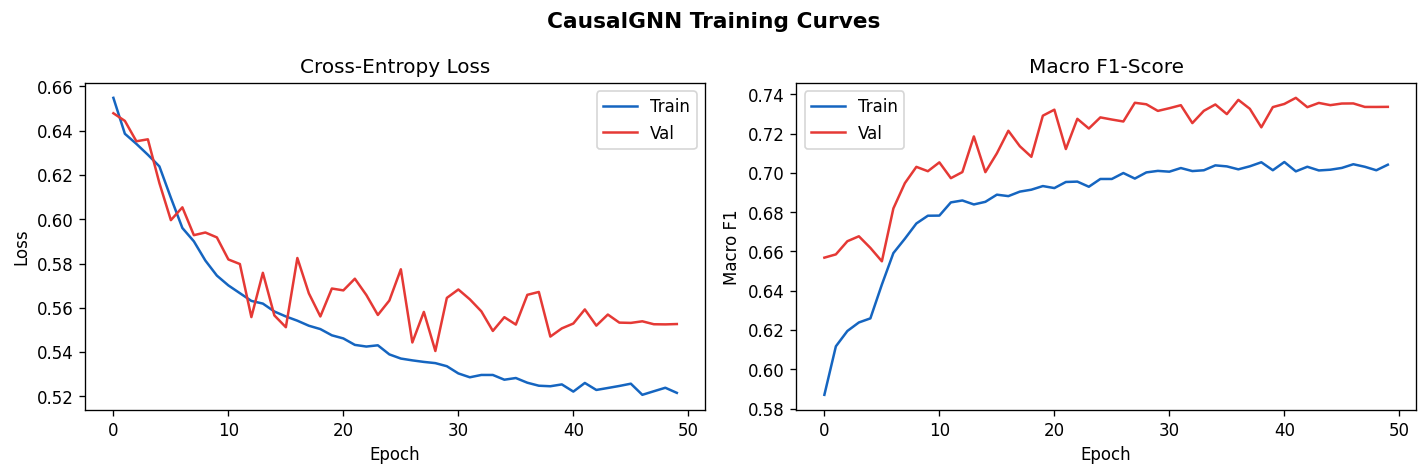

Saved → figures/fig_gnn_training_curves.png
Test Results — CausalGNN
  Macro F1  : 0.7033
  Binary F1 : 0.5522
  AUC-ROC   : 0.8079

              precision    recall  f1-score   support

      Normal       0.91      0.81      0.85     18849
        Risk       0.47      0.68      0.55      4721

    accuracy                           0.78     23570
   macro avg       0.69      0.74      0.70     23570
weighted avg       0.82      0.78      0.79     23570

Saved → results/metrics_causal_gnn.csv


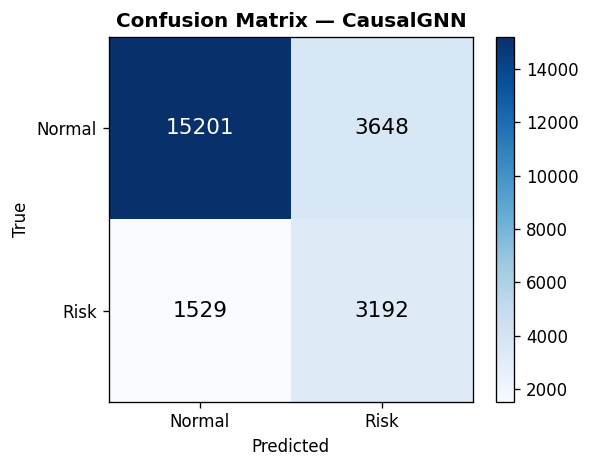

Saved → figures/fig_gnn_confusion.png

CausalGNN Complete — Summary for Paper

Architecture
────────────
  Input   : Sliding window W=6 (= tau_max) × 8 sensors
  Stage 1 : Temporal encoder  (1-D Conv per node)
  Stage 2 : Causal GAT × 2   (PCMCI edge structure)
  Stage 3 : Global mean pool  → MLP classifier

Causal edges used : 181
  (derived from stable_causal_links.csv, freq ≥ 50%)

Test performance
────────────────
  Macro F1  : 0.7033
  Binary F1 : 0.5522
  AUC-ROC   : 0.8079

Saved
─────
  results/best_causal_gnn.pt
  results/metrics_causal_gnn.csv
  figures/fig_gnn_training_curves.png
  figures/fig_gnn_confusion.png

Next step → 04_baseline.ipynb



In [1]:
# ============================================================
# Notebook : 03_causal_gnn.ipynb
# Path     : causal_fusion_paper/03_causal_gnn.ipynb
# Purpose  : Causal-Guided GNN Fusion Model for Elderly Risk Detection
#            Uses PCMCI-discovered causal adjacency as edge structure
# Author   : [Your Name]
# Created  : 2026-06-11
# ============================================================


# ── Cell 0. Imports & Paths ──────────────────────────────────
import warnings, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT    = Path().resolve()
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
CACHE   = ROOT / "data_cache"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


# ── Cell 1. Load Data & Causal Adjacency ────────────────────
df = pd.read_pickle(CACHE / "df_new.pkl")
ADJ = np.load(RES_DIR / "causal_adj.npy")   # (9, 9, 7)

SENSOR_COLS = [
    'Activity_IR', 'HeartRate', 'BreathRate',
    'StressIndex', 'Temperature', 'Humidity',
    'CO2', 'TVOC', 'Risk_bin',
]
# Node features: all sensors except Risk_bin (target)
FEAT_COLS = SENSOR_COLS[:-1]   # 8 sensors
N_NODES   = len(FEAT_COLS)
TAU_MAX   = 6

LABEL_MAP_BIN = {'위험': 1, '주의': 1,
                 '수면': 0, '식사': 0, '외출': 0, '기타': 0}
df['label'] = df['Estimation'].map(LABEL_MAP_BIN)
df = df[df['label'].notna()].copy()
df.sort_values(['HH_ID', 'Timestamp'], inplace=True)

# Remove Risk_bin source edges (prevent reverse causation leakage)
ADJ_FEAT = ADJ[:N_NODES, :N_NODES, :]   # (8, 8, 7)

print(f"Data shape       : {df.shape}")
print(f"Adjacency shape  : {ADJ_FEAT.shape}")
print(f"Positive labels  : {df['label'].mean()*100:.1f}%")


# ── Cell 2. Build Causal Edge Index ─────────────────────────
# Convert adjacency tensor to PyG edge_index and edge_attr.
# edge_attr encodes the lag at which the causal link was discovered.

def build_edge_index(adj: np.ndarray) -> tuple:
    """
    adj : (N, N, tau_max+1)  — causal adjacency
    Returns edge_index (2, E) and edge_attr (E, 1) tensors.
    Only edges from lag ≥ 1 (exclude instantaneous lag-0).
    """
    src, dst, lags = [], [], []
    N = adj.shape[0]
    for i in range(N):
        for j in range(N):
            for tau in range(1, adj.shape[2]):
                if adj[i, j, tau] == 1:
                    src.append(i)
                    dst.append(j)
                    lags.append(tau)
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(lags,       dtype=torch.float).unsqueeze(1)
    return edge_index, edge_attr

EDGE_INDEX, EDGE_ATTR = build_edge_index(ADJ_FEAT)
print(f"Causal edges     : {EDGE_INDEX.shape[1]}")
print(f"Sample edges (src→dst, lag):")
for k in range(min(5, EDGE_INDEX.shape[1])):
    s, d, l = EDGE_INDEX[0, k], EDGE_INDEX[1, k], EDGE_ATTR[k, 0]
    print(f"  {FEAT_COLS[s]:<15} → {FEAT_COLS[d]:<15}  τ={int(l)}")


# ── Cell 3. Sliding Window Dataset ──────────────────────────
# Each sample: window of W timesteps → predict label at t+1.
# Windows are built per household to avoid cross-household leakage.

WINDOW   = 6      # lookback window (= tau_max)
STRIDE   = 1      # slide step

class CausalWindowDataset(Dataset):
    """
    Builds sliding-window graph samples from multimodal time series.
    Each window produces one PyG Data object:
      x    : (N_nodes, W)  — sensor values across the window
      edge_index / edge_attr : causal graph structure
      y    : scalar binary label at the last step
      hh   : household ID (for group-based split)
    """
    def __init__(self, df, feat_cols, label_col,
                 edge_index, edge_attr, window=WINDOW, stride=STRIDE):
        self.samples    = []
        self.edge_index = edge_index
        self.edge_attr  = edge_attr

        scaler = StandardScaler()
        feat_all = df[feat_cols].values.astype(np.float32)
        feat_all = scaler.fit_transform(feat_all)

        for hh, grp in df.groupby('HH_ID'):
            idx   = grp.index
            feats = feat_all[df.index.get_indexer(idx)]   # (T, N)
            labs  = grp[label_col].values.astype(np.int64)

            for start in range(0, len(feats) - window, stride):
                x_win = feats[start: start + window]      # (W, N)
                y     = labs[start + window]
                if np.isnan(x_win).any():
                    continue
                # node features: transpose → (N, W)
                x_t = torch.tensor(x_win.T, dtype=torch.float)
                self.samples.append(
                    Data(x=x_t, edge_index=edge_index,
                         edge_attr=edge_attr,
                         y=torch.tensor(y, dtype=torch.long),
                         hh=hh)
                )

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


print("Building dataset …")
dataset = CausalWindowDataset(df, FEAT_COLS, 'label',
                              EDGE_INDEX, EDGE_ATTR)
print(f"Total samples : {len(dataset):,}")
print(f"Positive rate : {sum(s.y.item() for s in dataset)/len(dataset)*100:.1f}%")


# ── Cell 4. Train / Validation / Test Split ──────────────────
# Split by household (group split) to prevent data leakage.
# Train 70% / Val 15% / Test 15% of households.

hh_list  = sorted(df['HH_ID'].unique())
n        = len(hh_list)
n_train  = int(n * 0.70)
n_val    = int(n * 0.15)

rng      = np.random.default_rng(SEED)
hh_shuf  = rng.permutation(hh_list)
train_hh = set(hh_shuf[:n_train])
val_hh   = set(hh_shuf[n_train: n_train + n_val])
test_hh  = set(hh_shuf[n_train + n_val:])

train_data = [s for s in dataset if s.hh in train_hh]
val_data   = [s for s in dataset if s.hh in val_hh]
test_data  = [s for s in dataset if s.hh in test_hh]

print(f"\nHousehold split  : train {len(train_hh)} / val {len(val_hh)} / test {len(test_hh)}")
print(f"Sample split     : train {len(train_data):,} / val {len(val_data):,} / test {len(test_data):,}")

BATCH = 256
train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True,
                          collate_fn=Batch.from_data_list)
val_loader   = DataLoader(val_data,   batch_size=BATCH, shuffle=False,
                          collate_fn=Batch.from_data_list)
test_loader  = DataLoader(test_data,  batch_size=BATCH, shuffle=False,
                          collate_fn=Batch.from_data_list)


# ── Cell 5. Causal-Guided GNN Model ─────────────────────────
# Architecture:
#   1. Temporal encoder  : 1-D Conv over the window dimension per node
#   2. Causal GNN layers : GAT using PCMCI-derived edge structure
#   3. Global readout    : mean pooling over nodes
#   4. Classifier        : 2-layer MLP → binary output

class TemporalEncoder(nn.Module):
    """Per-node 1-D convolution over time window → node embedding."""
    def __init__(self, in_len, out_dim, kernel=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=kernel, padding=kernel//2),
            nn.ReLU(),
            nn.Conv1d(16, out_dim, kernel_size=kernel, padding=kernel//2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # collapse time → (out_dim,)
        )
    def forward(self, x):
        # x : (batch*N_nodes, in_len)
        return self.conv(x.unsqueeze(1)).squeeze(-1)   # (B*N, out_dim)


class CausalGNN(nn.Module):
    def __init__(self, n_nodes=N_NODES, window=WINDOW,
                 node_dim=32, gnn_dim=64, n_classes=2,
                 n_gat_heads=4, dropout=0.3):
        super().__init__()
        self.n_nodes = n_nodes

        # Temporal encoder (shared weights across nodes)
        self.temp_enc = TemporalEncoder(window, node_dim)

        # Two GAT layers with causal edge structure
        self.gat1 = GATConv(node_dim, gnn_dim,
                            heads=n_gat_heads, dropout=dropout,
                            edge_dim=1, concat=True)
        self.gat2 = GATConv(gnn_dim * n_gat_heads, gnn_dim,
                            heads=1, dropout=dropout,
                            edge_dim=1, concat=False)

        # Classifier
        self.clf = nn.Sequential(
            nn.Linear(gnn_dim, gnn_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gnn_dim // 2, n_classes),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, batch):
        x          = batch.x            # (total_nodes, W)  total_nodes = B*N
        edge_index = batch.edge_index   # already batched by PyG
        edge_attr  = batch.edge_attr

        # 1. Temporal encoding
        h = self.temp_enc(x)            # (total_nodes, node_dim)
        h = self.drop(h)

        # 2. Causal GNN
        h = F.elu(self.gat1(h, edge_index, edge_attr))
        h = self.drop(h)
        h = F.elu(self.gat2(h, edge_index, edge_attr))

        # 3. Global mean pooling per graph (batch)
        # batch.batch maps each node to its graph index
        from torch_geometric.nn import global_mean_pool
        h = global_mean_pool(h, batch.batch)   # (B, gnn_dim)

        return self.clf(h)              # (B, 2)


model = CausalGNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel : CausalGNN")
print(f"Trainable parameters : {total_params:,}")
print(model)


# ── Cell 6. Training Loop ────────────────────────────────────
# Class-weighted cross-entropy to handle imbalance (~3.4% Danger).

pos_weight = (df['label'] == 0).sum() / (df['label'] == 1).sum()
print(f"\nClass weight (neg/pos) : {pos_weight:.2f}")

EPOCHS = 50
LR     = 1e-3
WD     = 1e-4

class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
optimizer     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, trues = 0., [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch)
            loss   = criterion(logits, batch.y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(batch.y.cpu().numpy())
    n    = len(trues)
    f1   = f1_score(trues, preds, average='macro', zero_division=0)
    return total_loss / n, f1, trues, preds

history = {'train_loss': [], 'val_loss': [],
           'train_f1':   [], 'val_f1':   []}
best_val_f1, best_state = 0., None

print(f"\nTraining for {EPOCHS} epochs …\n")
print(f"{'Epoch':>5} {'TrainLoss':>10} {'TrainF1':>9} {'ValLoss':>9} {'ValF1':>8}")
print("-" * 46)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1, _, _  = run_epoch(train_loader, train=True)
    vl_loss, vl_f1, _, _  = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5} {tr_loss:>10.4f} {tr_f1:>9.4f} "
              f"{vl_loss:>9.4f} {vl_f1:>8.4f}")

torch.save(best_state, RES_DIR / "best_causal_gnn.pt")
print(f"\nBest val macro-F1 : {best_val_f1:.4f}")
print(f"Saved → results/best_causal_gnn.pt")


# ── Cell 7. Training Curves ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CausalGNN Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train', color='#1565C0')
axes[0].plot(history['val_loss'],   label='Val',   color='#E53935')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend()

axes[1].plot(history['train_f1'], label='Train', color='#1565C0')
axes[1].plot(history['val_f1'],   label='Val',   color='#E53935')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1-Score'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_gnn_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_gnn_training_curves.png")


# ── Cell 8. Test Evaluation ──────────────────────────────────
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
_, _, y_true, y_pred = run_epoch(test_loader, train=False)

# Probability for AUC
model.eval()
probs = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        prob  = F.softmax(model(batch), dim=1)[:, 1]
        probs.extend(prob.cpu().numpy())

macro_f1 = f1_score(y_true, y_pred, average='macro',  zero_division=0)
bin_f1   = f1_score(y_true, y_pred, average='binary', zero_division=0)
auc      = roc_auc_score(y_true, probs)

print("=" * 50)
print("Test Results — CausalGNN")
print("=" * 50)
print(f"  Macro F1  : {macro_f1:.4f}")
print(f"  Binary F1 : {bin_f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print()
print(classification_report(y_true, y_pred,
                             target_names=['Normal', 'Risk'],
                             zero_division=0))

# Save metrics
metrics = {
    'model':    'CausalGNN',
    'macro_f1': round(macro_f1, 4),
    'binary_f1': round(bin_f1,  4),
    'auc_roc':  round(auc,      4),
}
pd.DataFrame([metrics]).to_csv(RES_DIR / "metrics_causal_gnn.csv", index=False)
print("Saved → results/metrics_causal_gnn.csv")


# ── Cell 9. Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Risk']); ax.set_yticklabels(['Normal', 'Risk'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — CausalGNN', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=13, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_gnn_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_gnn_confusion.png")


# ── Cell 10. Summary ─────────────────────────────────────────
print(f"""
{'='*55}
CausalGNN Complete — Summary for Paper
{'='*55}

Architecture
────────────
  Input   : Sliding window W={WINDOW} (= tau_max) × {N_NODES} sensors
  Stage 1 : Temporal encoder  (1-D Conv per node)
  Stage 2 : Causal GAT × 2   (PCMCI edge structure)
  Stage 3 : Global mean pool  → MLP classifier

Causal edges used : {EDGE_INDEX.shape[1]}
  (derived from stable_causal_links.csv, freq ≥ 50%)

Test performance
────────────────
  Macro F1  : {macro_f1:.4f}
  Binary F1 : {bin_f1:.4f}
  AUC-ROC   : {auc:.4f}

Saved
─────
  results/best_causal_gnn.pt
  results/metrics_causal_gnn.csv
  figures/fig_gnn_training_curves.png
  figures/fig_gnn_confusion.png

Next step → 04_baseline.ipynb
""")